In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.5/fold0_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold0_05["fold"] = [0 for i in range(len(fold0_05))]
fold0_05["target"] = [-0.5 for i in range(len(fold0_05))]

In [3]:
fold1_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.5/fold1_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold1_05["fold"] = [1 for i in range(len(fold1_05))]
fold1_05["target"] = [-0.5 for i in range(len(fold1_05))]

In [4]:
fold2_05 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.5/fold2_-0.5_genomic_windows_table_results.tsv", sep="\t")

fold2_05["fold"] = [2 for i in range(len(fold2_05))]
fold2_05["target"] = [-0.5 for i in range(len(fold2_05))]

In [5]:
fold0_04 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.4/fold0_-0.4_genomic_windows_table_results.tsv", sep="\t")

fold0_04["fold"] = [0 for i in range(len(fold0_04))]
fold0_04["target"] = [-0.4 for i in range(len(fold0_04))]

In [6]:
fold1_04 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.4/fold1_-0.4_genomic_windows_table_results.tsv", sep="\t")

fold1_04["fold"] = [1 for i in range(len(fold1_04))]
fold1_04["target"] = [-0.4 for i in range(len(fold1_04))]

In [7]:
fold2_04 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.4/fold2_-0.4_genomic_windows_table_results.tsv", sep="\t")

fold2_04["fold"] = [2 for i in range(len(fold2_04))]
fold2_04["target"] = [-0.4 for i in range(len(fold2_04))]

In [8]:
fold0_03 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.3/fold0_-0.3_genomic_windows_table_results.tsv", sep="\t")

fold0_03["fold"] = [0 for i in range(len(fold0_03))]
fold0_03["target"] = [-0.3 for i in range(len(fold0_03))]

In [9]:
fold1_03 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.3/fold1_-0.3_genomic_windows_table_results.tsv", sep="\t")

fold1_03["fold"] = [1 for i in range(len(fold1_03))]
fold1_03["target"] = [-0.3 for i in range(len(fold1_03))]

In [10]:
fold2_03 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.3/fold2_-0.3_genomic_windows_table_results.tsv", sep="\t")

fold2_03["fold"] = [2 for i in range(len(fold2_03))]
fold2_03["target"] = [-0.3 for i in range(len(fold2_03))]

In [11]:
fold0_02 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.2/fold0_-0.2_genomic_windows_table_results.tsv", sep="\t")

fold0_02["fold"] = [0 for i in range(len(fold0_02))]
fold0_02["target"] = [-0.2 for i in range(len(fold0_02))]

In [12]:
fold1_02 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.2/fold1_-0.2_genomic_windows_table_results.tsv", sep="\t")

fold1_02["fold"] = [1 for i in range(len(fold1_02))]
fold1_02["target"] = [-0.2 for i in range(len(fold1_02))]

In [13]:
fold2_02 = pd.read_csv(f"/scratch1/smaruj/generate_genomic_boundary/overwritten_results/target_-0.2/fold2_-0.2_genomic_windows_table_results.tsv", sep="\t")

fold2_02["fold"] = [2 for i in range(len(fold2_02))]
fold2_02["target"] = [-0.2 for i in range(len(fold2_02))]

In [14]:
df = pd.concat([fold0_05, fold1_05, fold2_05, 
                fold0_04, fold1_04, fold2_04, 
                fold0_03, fold1_03, fold2_03, 
                fold0_02, fold1_02, fold2_02], ignore_index=True)

In [ ]:
df.columns

In [15]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [16]:
# optimizations with no edits
counts = df.groupby("target")["num_edits"].apply(lambda x: (x == 0).sum())
print(counts)

target
-0.5    25
-0.4    25
-0.3    24
-0.2    27
Name: num_edits, dtype: int64


### Is it the same 26 regions?

In [17]:
# Get regions where num_edits == 0 for each target
failed_regions = (
    df[df["num_edits"] == 0]
    .groupby("target")[["chrom", "centered_start", "centered_end"]]
    .apply(lambda g: set(zip(g["chrom"], g["centered_start"], g["centered_end"])))
)

# Check the intersection of all sets
common_failed = set.intersection(*failed_regions)

print(f"Common failed regions across all targets: {len(common_failed)}")
print(common_failed)

Common failed regions across all targets: 11
{('chr5', 82620416, 83931136), ('chrX', 60768256, 62078976), ('chr5', 41830400, 43141120), ('chr1', 159150080, 160460800), ('chr6', 102365184, 103675904), ('chr1', 185413632, 186724352), ('chr13', 34680832, 35991552), ('chr16', 14260224, 15570944), ('chr16', 62771200, 64081920), ('chr1', 78653440, 79964160), ('chr6', 65536000, 66846720)}


In [18]:
# eliminating them
df = df[df["num_edits"] > 0]

In [19]:
# optimizations with edits but not sufficent URQ score
urq_counts = df.groupby("target")["URQ_diff"].apply(lambda x: (x >= 0.0).sum())
print(urq_counts)

target
-0.5    0
-0.4    0
-0.3    0
-0.2    0
Name: URQ_diff, dtype: int64


In [20]:
# eliminating them
df = df[df["URQ_diff"] < 0.0]

In [21]:
len(df)

555

In [22]:
# successful optimizations only, average number of edits
avg_num_edits = df.groupby("target")["num_edits"].mean()
print(avg_num_edits)

target
-0.5    58.280576
-0.4    44.942446
-0.3    31.585714
-0.2    23.613139
Name: num_edits, dtype: float64


In [23]:
# successful optimizations only, average index of last step with accepted edits
avg_last_index = df.groupby("target")["last_accepted_step"].mean()
print(avg_last_index)

target
-0.5    1537.575540
-0.4    1445.395683
-0.3    1376.692857
-0.2    1337.218978
Name: last_accepted_step, dtype: float64


In [24]:
natural_results_path = "/scratch1/smaruj/natural_boundaries_URQmean/all_boundaries_URQ_mean.tsv"
nat_df = pd.read_csv(natural_results_path, sep="\t")

In [25]:
len(nat_df)

4474

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

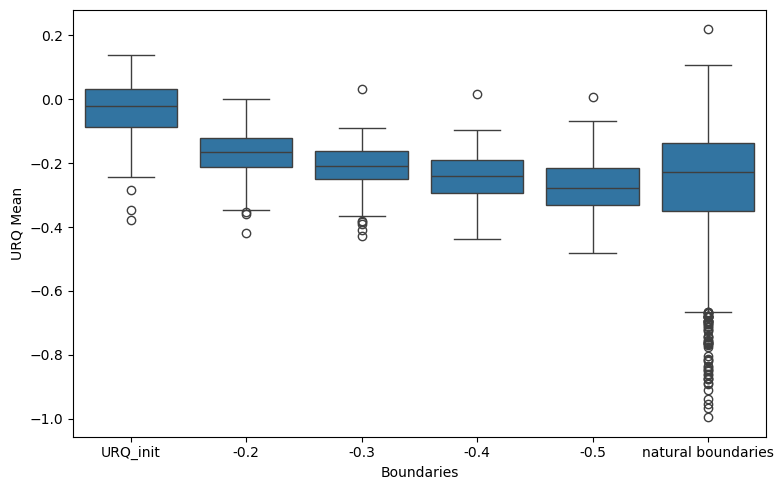

In [27]:
# 1. URQ_result for all targets
plot_df = df[['URQ_result', 'target']].copy()
plot_df['value'] = plot_df['URQ_result']
plot_df['group'] = plot_df['target'].astype(str)

# 3. URQ_mean from nat_df
nat_df_box = pd.DataFrame({
    'value': nat_df['URQ_mean'],
    'group': ['natural boundaries'] * len(nat_df)
})

# 2. URQ_init for target -0.5
init_subset = df[df['target'] == -0.5]
init_df = pd.DataFrame({
    'value': init_subset['URQ_init'],
    'group': ['URQ_init'] * len(init_subset)
})

# 4. Combine in desired order: URQ_mean, URQ_init, then URQ_result
combined_df = pd.concat(
    [init_df, plot_df[['value', 'group']], nat_df_box],
    ignore_index=True
)

# Define the desired order
order = ['URQ_init', '-0.2', '-0.3', '-0.4', '-0.5', 'natural boundaries']

# 5. Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='group', y='value', data=combined_df, order=order)
plt.xlabel("Boundaries")
plt.ylabel("URQ Mean")
plt.tight_layout()

plt.savefig("urq_mean_boundary_plot.svg", format="svg", bbox_inches="tight")

plt.show()


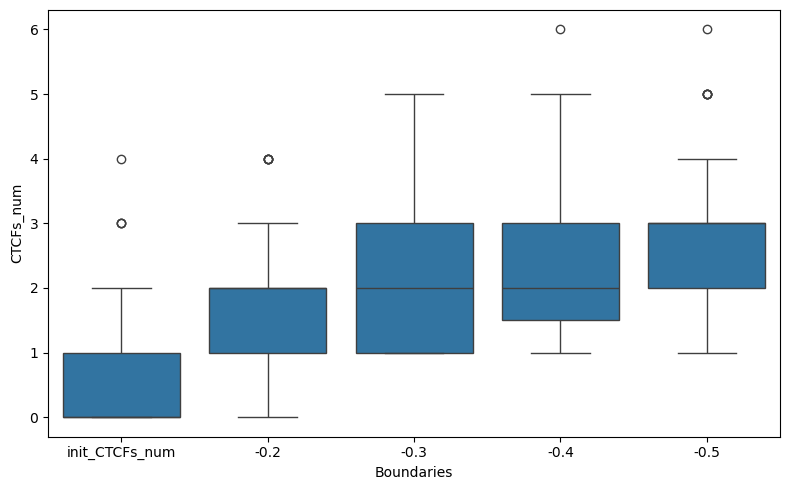

In [28]:
# 1. CTCFs_num for all targets
plot_df = df[['CTCFs_num', 'target']].copy()
plot_df['value'] = plot_df['CTCFs_num']
plot_df['group'] = plot_df['target'].astype(str)

# 2. init_CTCFs_num for target -0.5
init_subset = df[df['target'] == -0.5]
init_df = pd.DataFrame({
    'value': init_subset['init_CTCFs_num'],
    'group': ['init_CTCFs_num'] * len(init_subset)
})

# 3. Combine
combined_df = pd.concat([init_df, plot_df[['value', 'group']]], ignore_index=True)

# Define the desired order
order = ['init_CTCFs_num', '-0.2', '-0.3', '-0.4', '-0.5']

# 4. Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='group', y='value', data=combined_df, order=order)
plt.xlabel("Boundaries")
plt.ylabel("CTCFs_num")
# plt.title("CTCFs_num by Target Category with Initial CTCFs_num (-0.5)")
plt.tight_layout()

plt.savefig("ctcf_num_boundary_plot.svg", format="svg", bbox_inches="tight")

plt.show()

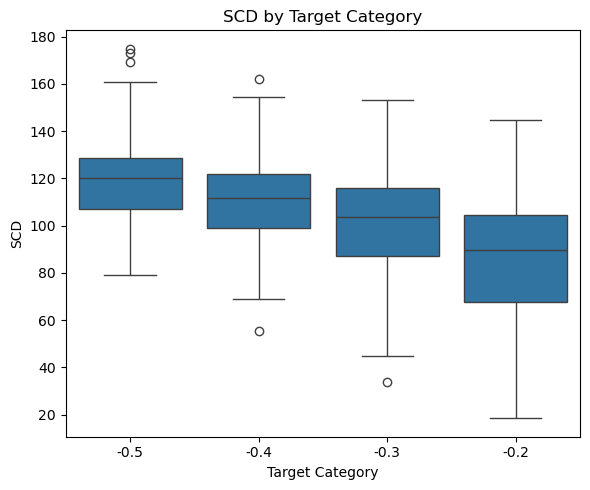

In [29]:
plot_df = df[['SCD', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='SCD', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("SCD")
plt.title("SCD by Target Category")
plt.tight_layout()
plt.show()

Pearson correlation: r = -0.349, p = 2.57e-17


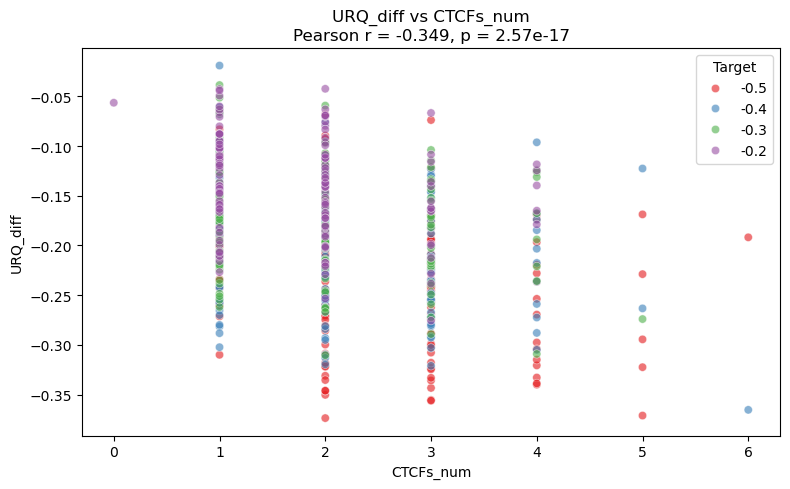

In [30]:
from scipy.stats import pearsonr

df['Target'] = df['target'].astype(str)

# 3. Combine all data
plot_df = pd.concat([df[['CTCFs_num', 'URQ_diff', 'Target']]], ignore_index=True)

# # 4. Pearson correlation over full data
corr, pval = pearsonr(plot_df['CTCFs_num'], plot_df['URQ_diff'])
print(f"Pearson correlation: r = {corr:.3f}, p = {pval:.3g}")

# 5. Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x='CTCFs_num',
    y='URQ_diff',
    hue='Target',
    palette='Set1',
    alpha=0.6
)
plt.xlabel("CTCFs_num")
plt.ylabel("URQ_diff")
plt.title(f"URQ_diff vs CTCFs_num\nPearson r = {corr:.3f}, p = {pval:.3g}")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

Pearson correlation (all targets + init): r = -0.443, p = 4.94e-28


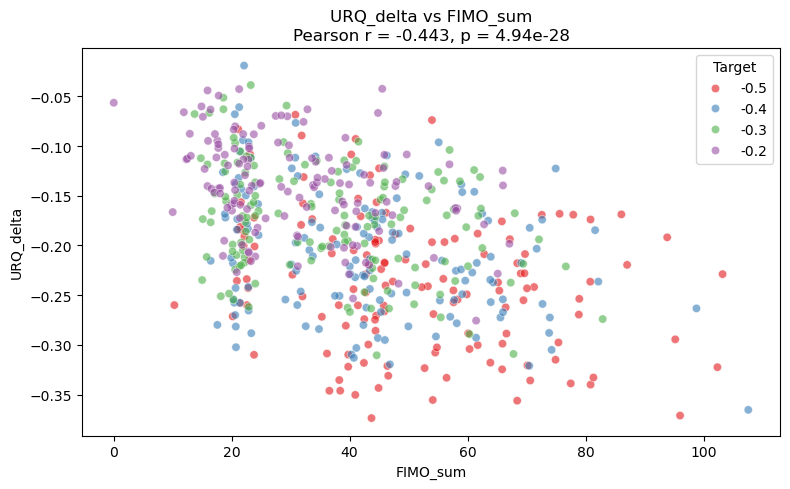

In [31]:
# 1. Compute URQ_delta for all relevant targets
subset = df[df['target'].isin([-0.5, -0.4, -0.3, -0.2])].copy()
subset['URQ_delta'] = subset['URQ_result'] - subset['URQ_init']
subset['Target'] = subset['target'].astype(str)  # Treat target as group label

# 3. Combine all data
plot_df = pd.concat([subset[['FIMO_sum', 'URQ_delta', 'Target']]], ignore_index=True)

# # 4. Pearson correlation over full data
corr, pval = pearsonr(plot_df['FIMO_sum'], plot_df['URQ_delta'])
print(f"Pearson correlation (all targets + init): r = {corr:.3f}, p = {pval:.3g}")

# 5. Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x='FIMO_sum',
    y='URQ_delta',
    hue='Target',
    palette='Set1',
    alpha=0.6
)
plt.xlabel("FIMO_sum")
plt.ylabel("URQ_delta")
plt.title(f"URQ_delta vs FIMO_sum\nPearson r = {corr:.3f}, p = {pval:.3g}")
plt.legend(title="Target")
plt.tight_layout()
plt.show()


Pearson correlation (all targets + init): r = -0.365, p = 6.21e-19


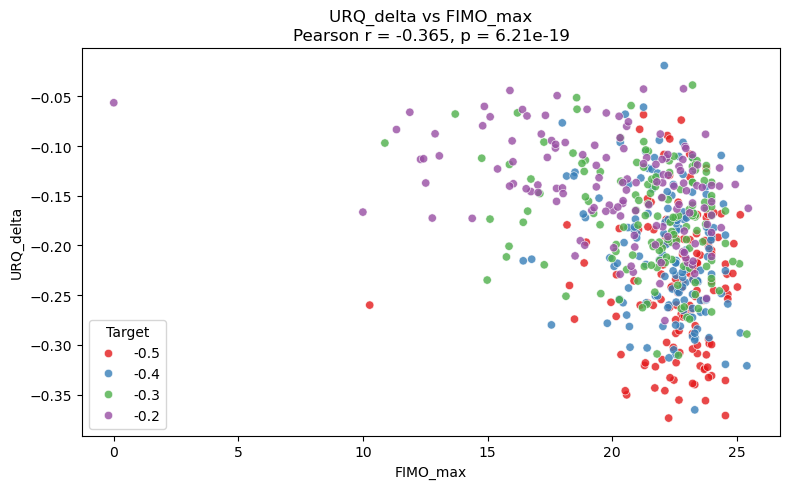

In [32]:
# 1. Compute URQ_delta for all relevant targets
subset = df[df['target'].isin([-0.5, -0.4, -0.3, -0.2])].copy()
subset['URQ_delta'] = subset['URQ_result'] - subset['URQ_init']
subset['Target'] = subset['target'].astype(str)  # Treat target as group label

# 3. Combine all data
plot_df = pd.concat([subset[['FIMO_max', 'URQ_delta', 'Target']]], ignore_index=True)

# # 4. Pearson correlation over full data
corr, pval = pearsonr(plot_df['FIMO_max'], plot_df['URQ_delta'])
print(f"Pearson correlation (all targets + init): r = {corr:.3f}, p = {pval:.3g}")

# 5. Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_df,
    x='FIMO_max',
    y='URQ_delta',
    hue='Target',
    palette='Set1',
    alpha=0.8
)
plt.xlabel("FIMO_max")
plt.ylabel("URQ_delta")
plt.title(f"URQ_delta vs FIMO_max\nPearson r = {corr:.3f}, p = {pval:.3g}")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

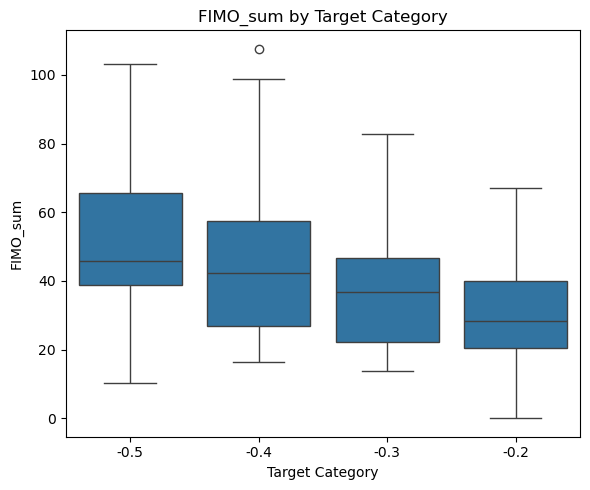

In [33]:
plot_df = df[['FIMO_sum', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='FIMO_sum', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("FIMO_sum")
plt.title("FIMO_sum by Target Category")
plt.tight_layout()
plt.show()

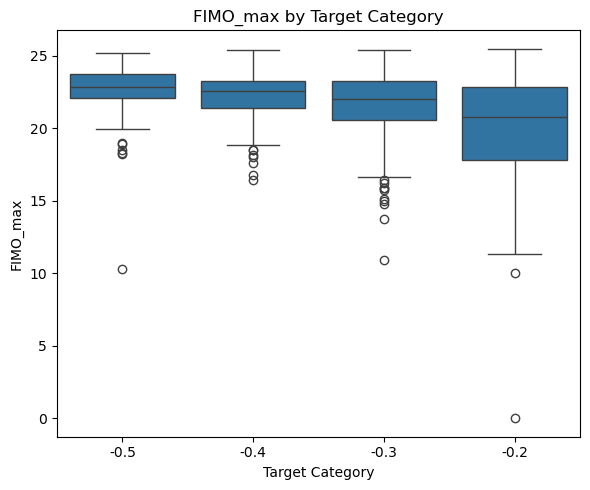

In [34]:
plot_df = df[['FIMO_max', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='FIMO_max', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("FIMO_max")
plt.title("FIMO_max by Target Category")
plt.tight_layout()
plt.show()

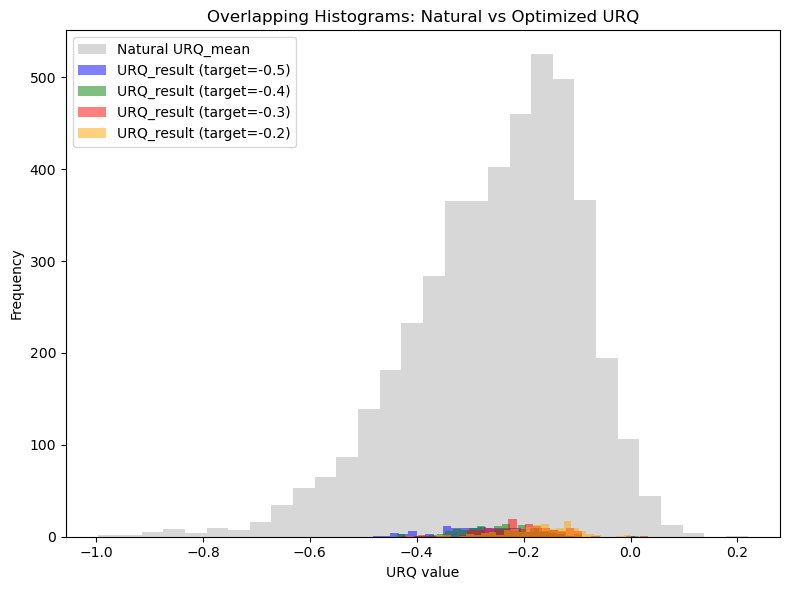

In [35]:
targets = [-0.5, -0.4, -0.3, -0.2]
colors = { -0.5: 'blue', -0.4: 'green', -0.3: 'red', -0.2: 'orange' }

plt.figure(figsize=(8, 6))

# Background histogram from natural data
plt.hist(nat_df["URQ_mean"], bins=30, color='lightgray', alpha=0.9, label='Natural URQ_mean')

# Overlay histograms for each target
for target in targets:
    subset = df[df["target"] == target]["URQ_result"]
    plt.hist(subset, bins=30, alpha=0.5, label=f'URQ_result (target={target})', color=colors[target])

plt.xlabel("URQ value")
plt.ylabel("Frequency")
plt.title("Overlapping Histograms: Natural vs Optimized URQ")
plt.legend()
plt.tight_layout()
plt.show()

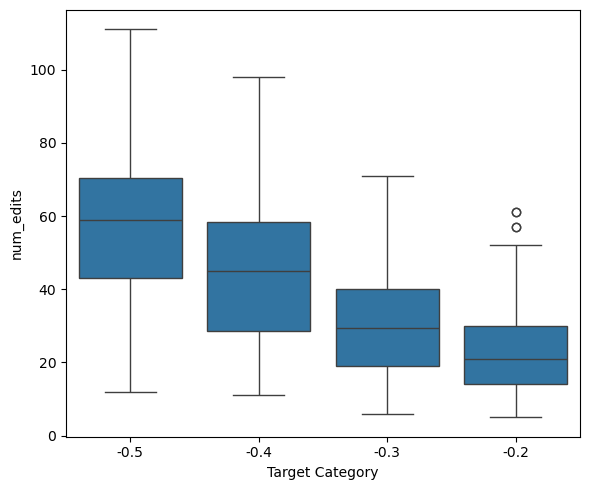

In [36]:
plot_df = df[['num_edits', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='num_edits', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("num_edits")
# plt.title("num_edits by Target Category")
plt.tight_layout()
plt.show()

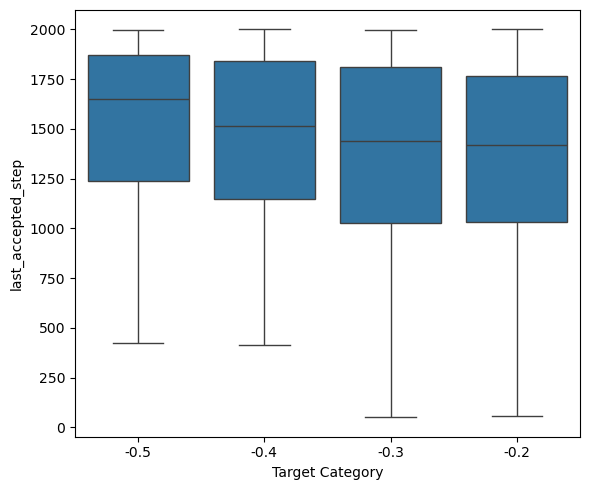

In [37]:
plot_df = df[['last_accepted_step', 'target']].copy()
plot_df['target'] = plot_df['target'].astype(str)

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='target', y='last_accepted_step', data=plot_df)
plt.xlabel("Target Category")
plt.ylabel("last_accepted_step")
# plt.title("num_edits by Target Category")
plt.tight_layout()
plt.show()

In [38]:
def canonicalize(ori):
    # Flip strand = replace + <-> -
    flipped = ori.replace("+", "x").replace("-", "+").replace("x", "-")
    # Pick lexicographically smaller string as canonical
    return min(ori, flipped)

In [39]:
df["orientation_canonical"] = df["orientation"].apply(canonicalize)

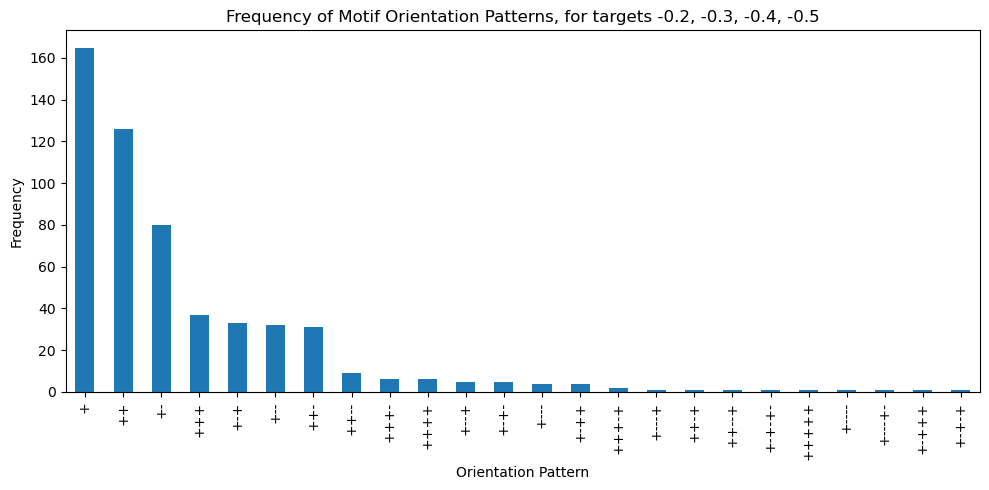

In [40]:
orientation_counts = df[df['orientation'] != "no"]['orientation_canonical'].value_counts()

# Plot
plt.figure(figsize=(10, 5))
orientation_counts.plot(kind='bar')
plt.xlabel("Orientation Pattern")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns, for targets -0.2, -0.3, -0.4, -0.5")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()